In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.shape # no of rows and columns

(100, 4)

In [6]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split   - called cross validation
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model



In [7]:
df.info() # give info about each col

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [8]:
#preprocessing

df = df.iloc[:,1:] # to remove 1st column

In [9]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


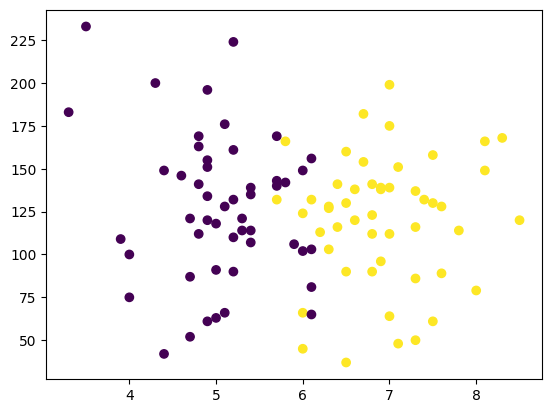

In [12]:
#EDA
import matplotlib.pyplot as plt

#c - for colour - yellow placed

plt.scatter(df['cgpa'],df['iq'],c=df['placement'])



In [13]:
# Feature selection ignored as we have only 2 input values
# and they are both required

In [14]:
# Extract Input and output cols


In [15]:
# to store independent variables

X = df.iloc[:,0:2] # all rows but cols 0-1 only
Y =df.iloc[:,-1] # all rows but only last col


In [16]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [17]:
Y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [22]:
# train tets split

from sklearn.model_selection import train_test_split

# independent and dep var and test size - here 0.1 - 10%
# train_test_split(X,Y,test_size=0.1)

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.1)

In [23]:
X_test

,cgpa,iq
37,8.1,149.0
84,5.7,169.0
47,5.2,161.0
61,7.3,137.0
50,3.5,233.0
1,5.9,106.0
64,7.0,64.0
69,8.5,120.0
31,3.9,109.0
77,7.3,50.0


In [24]:
# Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# will transform values from -1 to 1
X_train = scaler.fit_transform(X_train)


In [26]:
X_train

array([[ 0.12779533, -0.51902725],
       [ 0.22130411, -0.25806383],
       [-1.27483633,  0.60311546],
       [-1.18132755, -1.8499407 ],
       [-0.99431   ,  0.73359717],
       [-0.90080122, -1.56288094],
       [ 1.43691821,  0.91627157],
       [ 0.03428655,  0.02899594],
       [ 0.12779533,  0.23776667],
       [ 0.59533922,  0.39434473],
       [ 0.78235677,  0.00289959],
       [ 1.34340943,  0.23776667],
       [ 0.87586555,  0.39434473],
       [-0.80729244, -1.48459191],
       [-0.99431   ,  1.90793257],
       [-0.62027489, -0.23196749],
       [-1.08781878,  0.47263375],
       [-0.52676611, -0.23196749],
       [ 0.03428655, -2.03261509],
       [ 0.50183044, -2.24138583],
       [-0.71378367,  0.23776667],
       [-0.24623978,  0.52482644],
       [ 0.96937432, -0.28416017],
       [-1.08781878, -0.28416017],
       [ 1.0628831 , -1.95432607],
       [ 0.50183044, -0.8582797 ],
       [-0.71378367, -0.33635285],
       [ 1.53042699, -0.88437604],
       [ 0.31481288,

In [27]:
# we already get the pattern during above process to no need to fit_transform

X_test = scaler.transform(X_test)

In [28]:
X_test

array([[ 1.99797087,  0.68140449],
       [-0.24623978,  1.20333133],
       [-0.71378367,  0.9945606 ],
       [ 1.24990066,  0.36824838],
       [-2.30343288,  2.87349723],
       [-0.05922223, -0.44073822],
       [ 0.96937432, -1.53678459],
       [ 2.37200598, -0.07538943],
       [-1.92939777, -0.3624492 ],
       [ 1.24990066, -1.90213338]])

In [30]:
# training the model using Logistic regression


In [32]:
from sklearn.linear_model import LogisticRegression

In [36]:
clf = LogisticRegression()

In [38]:
# MOdel Training

In [40]:
#fit is used to train the model

clf.fit(X_train,Y_train)

LogisticRegression()

In [41]:
accuracy = clf.score(X_test, Y_test)

In [43]:
accuracy

1.0

In [ ]:
# Evaluate model

In [65]:
y_pred = clf.predict(X_test)

In [67]:
Y_test

,placement
37,1
84,0
47,0
61,1
50,0
1,0
64,1
69,1
31,0
77,1


In [71]:
# to check the accuracy of trained model
from sklearn.metrics import accuracy_score

accuracy_score(Y_test,y_pred)

1.0

<Axes: >

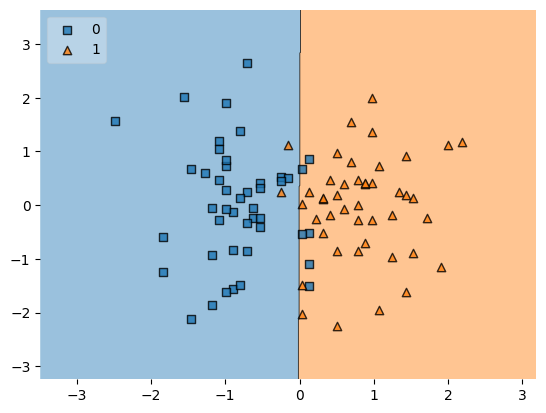

In [57]:
# To visualize pattern being used for decision making we use decision boundary
# we use library - mlextend

from mlxtend.plotting import plot_decision_regions

# values - to convert to numpy array
plot_decision_regions(X_train,Y_train.values,clf=clf, legend=2)

In [72]:
# to get the model

In [74]:
import pickle

# it will generate a file of model named " model.pkl"
pickle.dump(clf,open('model.pkl','wb'))